# ML Fundamentals - Hands On (runnable)

Covers everything in one place:
- **Supervised** learning (LABELED data) + prediction
- **Unsupervised** learning (UNLABELED data = clustering)
- **Model fitting** (training)
- **Graphs**: data in 2D, confusion matrix, cluster plot, training loss curve
- A **neural network with multiple hidden layers** and its **weights**

**How to run:** open in VS Code -> Select Kernel -> the project's `.venv` ->
run each cell with Shift+Enter, top to bottom.

In [1]:
# Cell 1 - tools + data (text -> embeddings = our features X)
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

embedder = SentenceTransformer("BAAI/bge-small-en-v1.5")

training = [
    ("The patient presents with hypertension. BP 150/95.",        "Physician Note"),
    ("Assessment: type 2 diabetes on metformin. Plan: continue.",  "Physician Note"),
    ("Chief complaint: headaches. Start medication, follow up.",   "Physician Note"),
    ("Physical exam unremarkable. Reports chest discomfort.",      "Physician Note"),
    ("Plan: reduce salt, exercise, recheck in four weeks.",        "Physician Note"),
    ("Follow-up care: finish antibiotics, see doctor in a week.",  "Discharge Summary"),
    ("Hospital course: pneumonia, IV antibiotics, improved.",      "Discharge Summary"),
    ("Discharge instructions: return to ER if fever returns.",     "Discharge Summary"),
    ("Patient discharged in stable condition after three days.",   "Discharge Summary"),
    ("Reason for admission: pneumonia. Discharged home.",          "Discharge Summary"),
    ("Fasting glucose 138 high. Cholesterol 220 borderline.",      "Lab Report"),
    ("Results: LDL 145, HDL 40. Repeat testing advised.",          "Lab Report"),
    ("Metabolic panel: elevated glucose. Lipid profile abnormal.", "Lab Report"),
    ("Hemoglobin A1c 7.8 percent, above target.",                  "Lab Report"),
    ("Panel: sodium 140, potassium 4.2, creatinine normal.",       "Lab Report"),
]
texts  = [t for t, l in training]
labels = [l for t, l in training]
X = embedder.encode(texts, normalize_embeddings=True)   # FEATURES (15 x 384)
print("X (features):", X.shape, " labels:", len(labels))

c:\Users\MMS\Documents\Personal AI projects\ai-ml-projects\tenet-clinical-ai\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X (features): (15, 384)  labels: 15


## Part 1 - SUPERVISED learning (LABELED data)

'Supervised' = we give the model the **right answers (labels)** to learn from.
We fit a classifier, then use it to **predict**.

In [2]:
# Cell 2 - fit a classifier on labeled data, then predict
clf = LogisticRegression(max_iter=1000)
clf.fit(X, labels)                       # FITTING = learning from labeled data
pred = clf.predict(X[:1])                # PREDICT
print("First text predicted as:", pred[0])
print("Training accuracy:", accuracy_score(labels, clf.predict(X)))

First text predicted as: Physician Note
Training accuracy: 1.0


## Graph 1 - see the data in 2D (colored by label)

Our features are 384-dimensional (can't draw that). **PCA** squashes them to 2D
so we can plot them. Each point = one document, colored by its true type.
If the colors form separate groups, the classes are easy to tell apart.

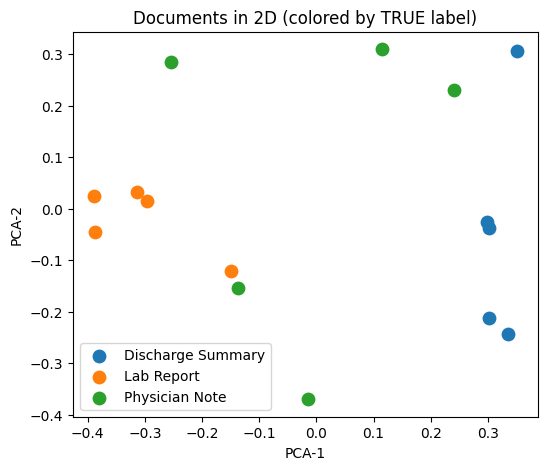

In [3]:
# Cell 3 - plot the 384-D features in 2D using PCA
coords = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(6,5))
for label in sorted(set(labels)):
    idx = [i for i,l in enumerate(labels) if l == label]
    plt.scatter(coords[idx,0], coords[idx,1], label=label, s=80)
plt.legend(); plt.title("Documents in 2D (colored by TRUE label)")
plt.xlabel("PCA-1"); plt.ylabel("PCA-2")
plt.show()

## Graph 2 - Confusion Matrix (where does it make mistakes?)

We split into train/test, predict on the test set, and draw a **confusion
matrix**: rows = true type, columns = predicted type. The diagonal = correct.

Test accuracy: 0.6666666666666666


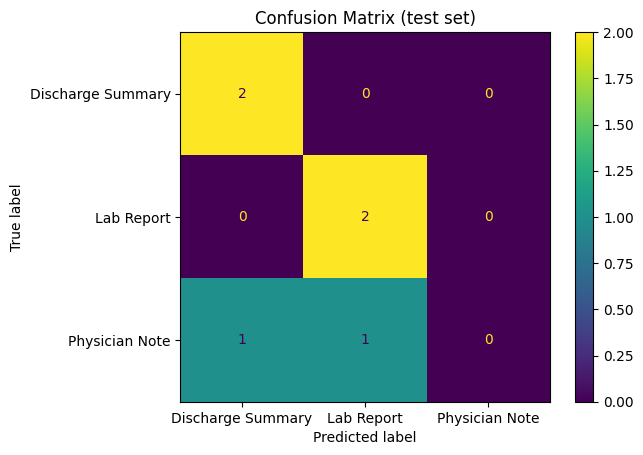

In [4]:
# Cell 4 - train/test + confusion matrix
X_tr, X_te, y_tr, y_te = train_test_split(X, labels, test_size=0.4, random_state=0, stratify=labels)
m = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
print("Test accuracy:", accuracy_score(y_te, m.predict(X_te)))
ConfusionMatrixDisplay.from_predictions(y_te, m.predict(X_te))
plt.title("Confusion Matrix (test set)")
plt.show()

## Part 2 - UNSUPERVISED learning (UNLABELED data = clustering)

Now we HIDE the labels. The model must find groups **on its own**.
**KMeans** groups points into K clusters by similarity. This is how customer
segmentation works (Project 2).

Cluster assigned to each document: [1 1 0 1 2 0 0 0 0 0 1 1 1 1 1]


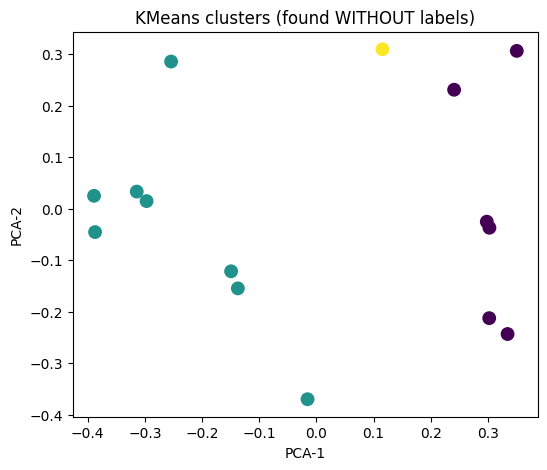

In [5]:
# Cell 5 - cluster WITHOUT labels, then plot the clusters
km = KMeans(n_clusters=3, n_init=10, random_state=0)
clusters = km.fit_predict(X)             # NO labels given!
print("Cluster assigned to each document:", clusters)

plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], c=clusters, cmap="viridis", s=80)
plt.title("KMeans clusters (found WITHOUT labels)")
plt.xlabel("PCA-1"); plt.ylabel("PCA-2")
plt.show()

## Part 3 - a NEURAL NETWORK with multiple hidden layers

Logistic Regression had 0 hidden layers. Now we use an **MLP (Multi-Layer
Perceptron)** = a real neural network with **hidden layers**. We set two hidden
layers of sizes 16 and 8. We then inspect the **weight matrix of each layer**.

In [6]:
# Cell 6 - a multi-layer neural network + inspect its weights
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=2000, random_state=0)
mlp.fit(X_tr, y_tr)
print("Test accuracy:", accuracy_score(y_te, mlp.predict(X_te)))
print()
print("Network shape: 384 inputs -> 16 -> 8 -> 3 outputs")
print("WEIGHT matrix per layer connection (mlp.coefs_):")
for i, W in enumerate(mlp.coefs_, 1):
    print(f"  layer {i}: shape {W.shape}  ({W.shape[0]} in -> {W.shape[1]} out)")
total = sum(W.size for W in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
print("Total learned numbers (weights+biases):", total)

Test accuracy: 0.6666666666666666

Network shape: 384 inputs -> 16 -> 8 -> 3 outputs
WEIGHT matrix per layer connection (mlp.coefs_):
  layer 1: shape (384, 16)  (384 in -> 16 out)
  layer 2: shape (16, 8)  (16 in -> 8 out)
  layer 3: shape (8, 3)  (8 in -> 3 out)
Total learned numbers (weights+biases): 6323


## Graph 3 - the training LOSS curve (watch it 'fit')

As the neural network trains, its **loss** (error) should go DOWN. This curve is
literally the model 'adjusting to the data' step by step.

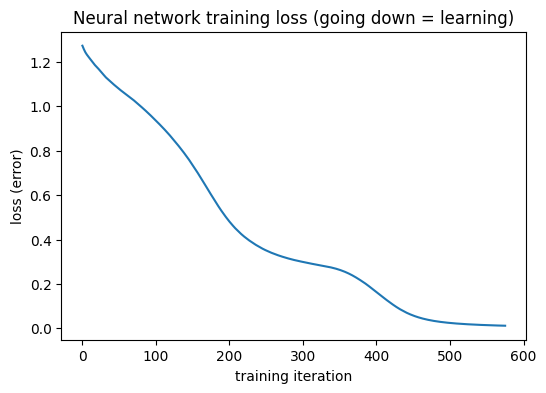

In [7]:
# Cell 7 - plot the loss going down during training
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_)
plt.title("Neural network training loss (going down = learning)")
plt.xlabel("training iteration"); plt.ylabel("loss (error)")
plt.show()

## Summary - you have now seen, hands-on:

| Concept | Cell |
|---|---|
| Features (X = embeddings) | 1 |
| Supervised learning (labeled) + fit + predict | 2 |
| Graph: data in 2D (PCA) | 3 |
| Graph: confusion matrix | 4 |
| Unsupervised learning (unlabeled) = clustering | 5 |
| Neural network with hidden layers + weights | 6 |
| Graph: training loss curve | 7 |

Change things and re-run: add data, change `hidden_layer_sizes=(32,16,8)`,
or `n_clusters=4`, and watch what happens.